Environment

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
import matplotlib.pyplot as plt
from PIL import Image
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids
from scipy.stats import shapiro, chisquare, poisson, pearsonr
from predict_loop_functions import visual_prediction, generate_noise, ensure_2d_list, get_neuron_units

In [2]:
def predict_loop(noise_type, noise_seeds, image, sigma, scans):
    """
    Parameters
    ----------
    noise_type: string
        dynamic, constant, or no noise NOTE: make stochastic binarization a parameter here
    noise_seeds: int
        how many times we add noise to the prediction
    image: object
        image that we are adding noise to and then predicting on, ie like the frames object below
    sigma: int
        standard deviation for gaussian noise distribution
    scans: list/array
        should be 2d array with pairs of sessions and scan ids taken from scans.csv
    
    Returns
    -------
    array
        returns array with predictions for all neurons
    
    ex. input predict_loop("constant", 100, image, 3, [[4,6], [5,7]])
    """
    scans = ensure_2d_list(scans)
    num_neurons = get_neuron_units(scans)
    num_frames = image.shape[0]

    noise_results = np.empty((noise_seeds, num_frames, num_neurons))

    for noise_i in range(noise_seeds):
                    
        new_noise = generate_noise(noise_type, num_frames, sigma)

        new_image = (image + new_noise).astype('uint8')
        for pair in scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_image) 
            # ralf's comment about pixel_value/256 being chance of pixel value being changed to 255, add code here? should be per noise seed

            try:
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results[noise_i] = final_concat1_std4
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds

    return noise_stack

#### imagenet

In [3]:
imagenet_path = "C://Users//joshf//Downloads//imagenet-mini"

In [4]:
# use train data for now

train_path = imagenet_path + "//train"

files = [file for file in os.listdir(train_path)]

In [9]:
files[0]

'n01440764'

In [12]:
test_file = train_path + '//n01440764'
files = os.listdir(test_file)

In [13]:
files

['n01440764_10043.JPEG',
 'n01440764_10470.JPEG',
 'n01440764_10744.JPEG',
 'n01440764_10845.JPEG',
 'n01440764_11170.JPEG',
 'n01440764_12021.JPEG',
 'n01440764_12063.JPEG',
 'n01440764_12090.JPEG',
 'n01440764_12329.JPEG',
 'n01440764_12435.JPEG',
 'n01440764_12534.JPEG',
 'n01440764_13545.JPEG',
 'n01440764_14411.JPEG',
 'n01440764_14448.JPEG',
 'n01440764_14731.JPEG',
 'n01440764_15071.JPEG',
 'n01440764_15560.JPEG',
 'n01440764_1775.JPEG',
 'n01440764_31518.JPEG',
 'n01440764_3236.JPEG',
 'n01440764_3603.JPEG',
 'n01440764_4397.JPEG',
 'n01440764_4852.JPEG',
 'n01440764_4965.JPEG',
 'n01440764_4979.JPEG',
 'n01440764_5087.JPEG',
 'n01440764_5376.JPEG',
 'n01440764_5638.JPEG',
 'n01440764_5785.JPEG',
 'n01440764_6206.JPEG',
 'n01440764_6425.JPEG',
 'n01440764_8710.JPEG',
 'n01440764_9157.JPEG',
 'n01440764_9779.JPEG']

In [16]:
opened_file = Image.open(str(test_file + '//n01440764_6206.JPEG'))

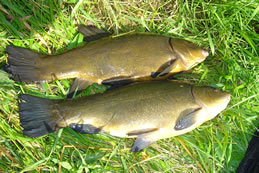

In [17]:
opened_file